# 00 — MNIST Learning Map (TensorFlow / Keras)

> **Goal:** understand an ANN as an inspectable system rather than a black box. All three orphan branches use the same official MNIST archive, the same balanced teaching subset, and the same learning objectives.

## Shared experiment contract
- official MNIST 28×28 handwritten digits
- 5,000 balanced training samples (500/class)
- 1,000 balanced test samples (100/class)
- normalized pixel input: 784 values in [0,1]
- primary classifier: 784 → 64 → 10
- representation lab: 784 → 2 → 10
- fixed seeds where randomness is used
- loss, accuracy, confusion matrix, confidence/error analysis


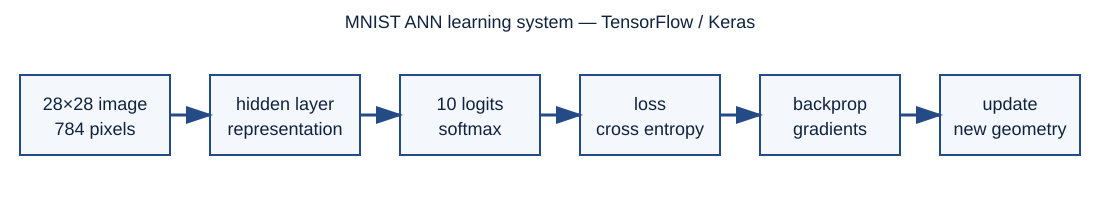

In [1]:
from IPython.display import SVG,display
display(SVG(filename='visual_learning/ann_system_map.svg'))


## Core mathematics

Forward propagation:
$$
\mathbf{x}\to \mathbf{z}^{(1)}=\mathbf{x}W^{(1)}+\mathbf{b}^{(1)}\to
\mathbf{a}^{(1)}=\phi(\mathbf{z}^{(1)})\to
\mathbf{z}^{(2)}=\mathbf{a}^{(1)}W^{(2)}+\mathbf{b}^{(2)}\to
\hat{\mathbf y}=\operatorname{softmax}(\mathbf{z}^{(2)})
$$

Learning uses the loss to send sensitivity backward:
$$
\mathcal L\to \nabla W^{(2)}\to \nabla W^{(1)}\to \text{updated parameters}
$$

**Forward pass = current belief. Backpropagation = responsibility assignment. Optimizer = correction.**


train (5000, 784) test (1000, 784)


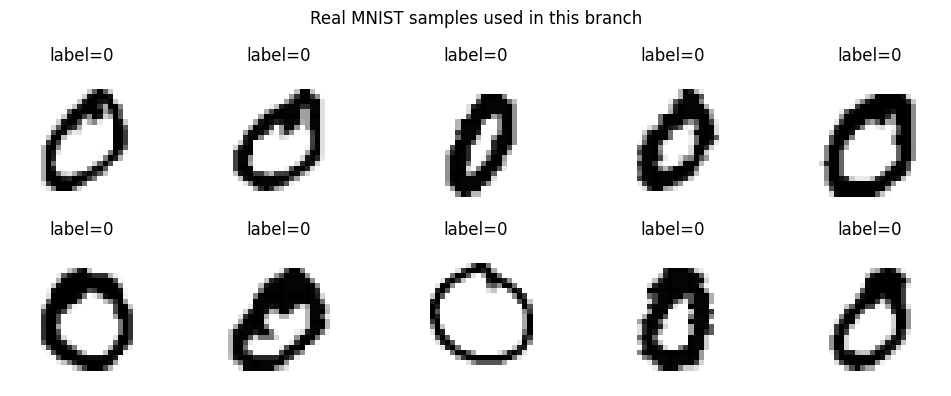

In [2]:
from pathlib import Path
import urllib.request, numpy as np
MNIST_URL='https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
CACHE=Path('data/cache/mnist.npz'); CACHE.parent.mkdir(parents=True,exist_ok=True)
if not CACHE.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL,CACHE)
with np.load(CACHE) as d:
    x_train_full,y_train_full=d['x_train'],d['y_train']
    x_test_full,y_test_full=d['x_test'],d['y_test']
def balanced(x,y,n):
    ids=np.concatenate([np.flatnonzero(y==c)[:n] for c in range(10)])
    return x[ids],y[ids]
x_train_img,y_train=balanced(x_train_full,y_train_full,500)
x_test_img,y_test=balanced(x_test_full,y_test_full,100)
x_train=x_train_img.reshape(len(x_train_img),-1).astype('float32')/255.0
x_test=x_test_img.reshape(len(x_test_img),-1).astype('float32')/255.0
print('train',x_train.shape,'test',x_test.shape)

import matplotlib.pyplot as plt
fig,axes=plt.subplots(2,5,figsize=(10,4))
for ax,img,label in zip(axes.ravel(),x_train_img[:10],y_train[:10]): ax.imshow(img,cmap='gray_r');ax.set_title(f'label={label}');ax.axis('off')
plt.suptitle('Real MNIST samples used in this branch');plt.tight_layout();plt.show()


## Reading order
1. Pixels and one neuron
2. Forward propagation
3. Loss, gradients, and backpropagation
4. Training and representation learning
5. Inference, debugging, and business decisions

Every notebook combines **intuition + mathematics + numerical calculation + code + visualization + inference + production/business interpretation**.
